In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os  # Necessario per costruire i percorsi dei file

# --- 1. IMPOSTAZIONI "CASARECCE" (Come richiesto) ---
BASE_PATH = r'C:\Users\nicol\Thesis\DATA real time\_test_raw'
SUBJECT_ID = '17' # Variabile per il soggetto

# Lista delle prove: ogni prova è una tupla (nome_cartella, nome_sottocartella)
TRIALS_TO_PROCESS = [
    ('test1a', '1'),
    ('test1a', '2'),
    ('test1b', '1'),
    ('test2a', '3'),
    ('test2a', '4'),
    ('test2b', '5'),
]

# Impostazioni di campionamento (usate solo per il PRIMO batch)
SAMPLING_FREQ_HZ = 50  
DELTA_T_MS = 1000 / SAMPLING_FREQ_HZ

# Dizionario "casareccio" dove salveremo tutti i DataFrame processati
# La chiave sarà il nome della prova (es. "test1a_1")
processed_dataframes = {}

print(f"--- Avvio elaborazione per Soggetto: {SUBJECT_ID} ---")

# --- 2. LOOP PRINCIPALE (per ogni prova) ---
for test_folder, sub_folder in TRIALS_TO_PROCESS:
    
    # Crea un nome "chiave" per questa prova, es: "test1a_1"
    trial_key = f"{test_folder}_{sub_folder}"
    
    print(f"\n--- Elaborazione prova: {trial_key} ---")

    # --- 3. Costruzione dinamica del percorso ---
    file_path = os.path.join(BASE_PATH, f'S{SUBJECT_ID}', test_folder, sub_folder, 'raw_emg_imu.csv')

    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"ATTENZIONE: File non trovato, salto. {file_path}")
        continue # Salta al prossimo ciclo del loop

    # --- 4. SELEZIONE E PULIZIA DATI ---
    colonne_imu = ['Timestamps', 'ACC_X', 'ACC_Y', 'ACC_Z', 'GYR_X', 'GYR_Y', 'GYR_Z']
    imu_columns_data_only = ['ACC_X', 'ACC_Y', 'ACC_Z', 'GYR_X', 'GYR_Y', 'GYR_Z'] # Colonne solo dati
    
    df_imu = df[colonne_imu].copy()

    print(f"Dati originali: {len(df_imu)} righe")

    # PULIZIA 1: Rimuovi i duplicati "fill-down" (come da tua richiesta)
    df_pulito = df_imu.drop_duplicates(subset=imu_columns_data_only)
    
    # PULIZIA 2: Rimuovi le righe "all-zero" (logica corretta)
    # Tieni solo le righe che NON (~) sono tutte (all) 0 nelle colonne IMU
    df_pulito = df_pulito[~(df_pulito[imu_columns_data_only] == 0).all(axis=1)]

    print(f"Dati dopo pulizia: {len(df_pulito)} righe")

    # --- 5. RICOSTRUZIONE TIMESTAMP ---
    unique_timestamps_str = df_pulito['Timestamps'].unique()
    # errors='coerce' trasforma timestamp corrotti in 'NaT' (Not a Time)
    unique_timestamps_dt = pd.to_datetime(unique_timestamps_str, format='%H_%M_%S_%f', errors='coerce')
    
    # Pulisci da eventuali NaT
    valid_mask = pd.notna(unique_timestamps_dt)
    unique_timestamps_dt = unique_timestamps_dt[valid_mask]
    unique_timestamps_str = unique_timestamps_str[valid_mask]

    new_data_frames = []

    for i in range(len(unique_timestamps_dt)):
        
        current_timestamp_str = unique_timestamps_str[i]
        T_end = unique_timestamps_dt[i] # Timestamp del batch corrente
        
        batch_data = df_pulito[df_pulito['Timestamps'] == current_timestamp_str]
        num_samples = len(batch_data)
        
        new_times = []
        
        if i == 0:
            # --- CASO SPECIALE: PRIMO BATCH (La tua logica 20ms) ---
            offsets_ms = np.arange(num_samples - 1, -1, -1) * DELTA_T_MS
            new_times = T_end - pd.to_timedelta(offsets_ms, unit='ms')
            
        else:
            # --- CASI SUCCESSIVI (La tua logica linspace) ---
            T_start = unique_timestamps_dt[i-1] # Timestamp (fine) del batch precedente
            
            # Crea N+1 punti tra T_start e T_end
            all_times_in_interval = np.linspace(T_start.value, T_end.value, num_samples + 1, endpoint=True)
            
            # Prendi gli ultimi N punti (escludendo T_start e includendo T_end)
            new_times = pd.to_datetime(all_times_in_interval[1:])

        # Assegna i nuovi timestamp ai dati del batch
        batch_data_resampled = batch_data.copy()
        batch_data_resampled['datetime'] = new_times
        new_data_frames.append(batch_data_resampled)

    # --- 6. FINALIZZAZIONE E SALVATAGGIO ---
    if not new_data_frames: # Controlla se abbiamo effettivamente processato qualcosa
        print(f"ATTENZIONE: Nessun dato valido da salvare per {trial_key}. Salto.")
        continue
        
    # Concatena tutti i mini-batch in un unico DataFrame
    df_resampled = pd.concat(new_data_frames)
    df_resampled = df_resampled.set_index('datetime').sort_index()
    df_resampled = df_resampled.drop(columns=['Timestamps']) # Rimuovi la vecchia colonna
    
    # Salva il DataFrame processato nel nostro dizionario
    processed_dataframes[trial_key] = df_resampled
    print(f"Completato. DataFrame '{trial_key}' creato e salvato in 'processed_dataframes'.")


# --- 7. FINE ELABORAZIONE ---
print("\n--- Elaborazione di tutti i file completata ---")
print(f"DataFrame disponibili nel dizionario: {list(processed_dataframes.keys())}")

# --- Esempio di come usare i dati dopo il loop ---
if 'test1a_1' in processed_dataframes:
    print("\nMostro le prime 5 righe di 'test1a_1':")
    print(processed_dataframes['test1a_1'].head())
    
    # Esempio di plotting per il primo DataFrame

--- Avvio elaborazione per Soggetto: 17 ---

--- Elaborazione prova: test1a_1 ---
Dati originali: 18333 righe
Dati dopo pulizia: 6792 righe
Completato. DataFrame 'test1a_1' creato e salvato in 'processed_dataframes'.

--- Elaborazione prova: test1a_2 ---
Dati originali: 17766 righe
Dati dopo pulizia: 6638 righe
Completato. DataFrame 'test1a_2' creato e salvato in 'processed_dataframes'.

--- Elaborazione prova: test1b_1 ---
Dati originali: 25478 righe
Dati dopo pulizia: 11254 righe
Completato. DataFrame 'test1b_1' creato e salvato in 'processed_dataframes'.

--- Elaborazione prova: test2a_3 ---
Dati originali: 5430 righe
Dati dopo pulizia: 2311 righe
Completato. DataFrame 'test2a_3' creato e salvato in 'processed_dataframes'.

--- Elaborazione prova: test2a_4 ---
Dati originali: 5989 righe
Dati dopo pulizia: 2752 righe
Completato. DataFrame 'test2a_4' creato e salvato in 'processed_dataframes'.

--- Elaborazione prova: test2b_5 ---
Dati originali: 10495 righe
Dati dopo pulizia: 4825 ri


--- Genero i grafici di esempio per: test1a_1 ---


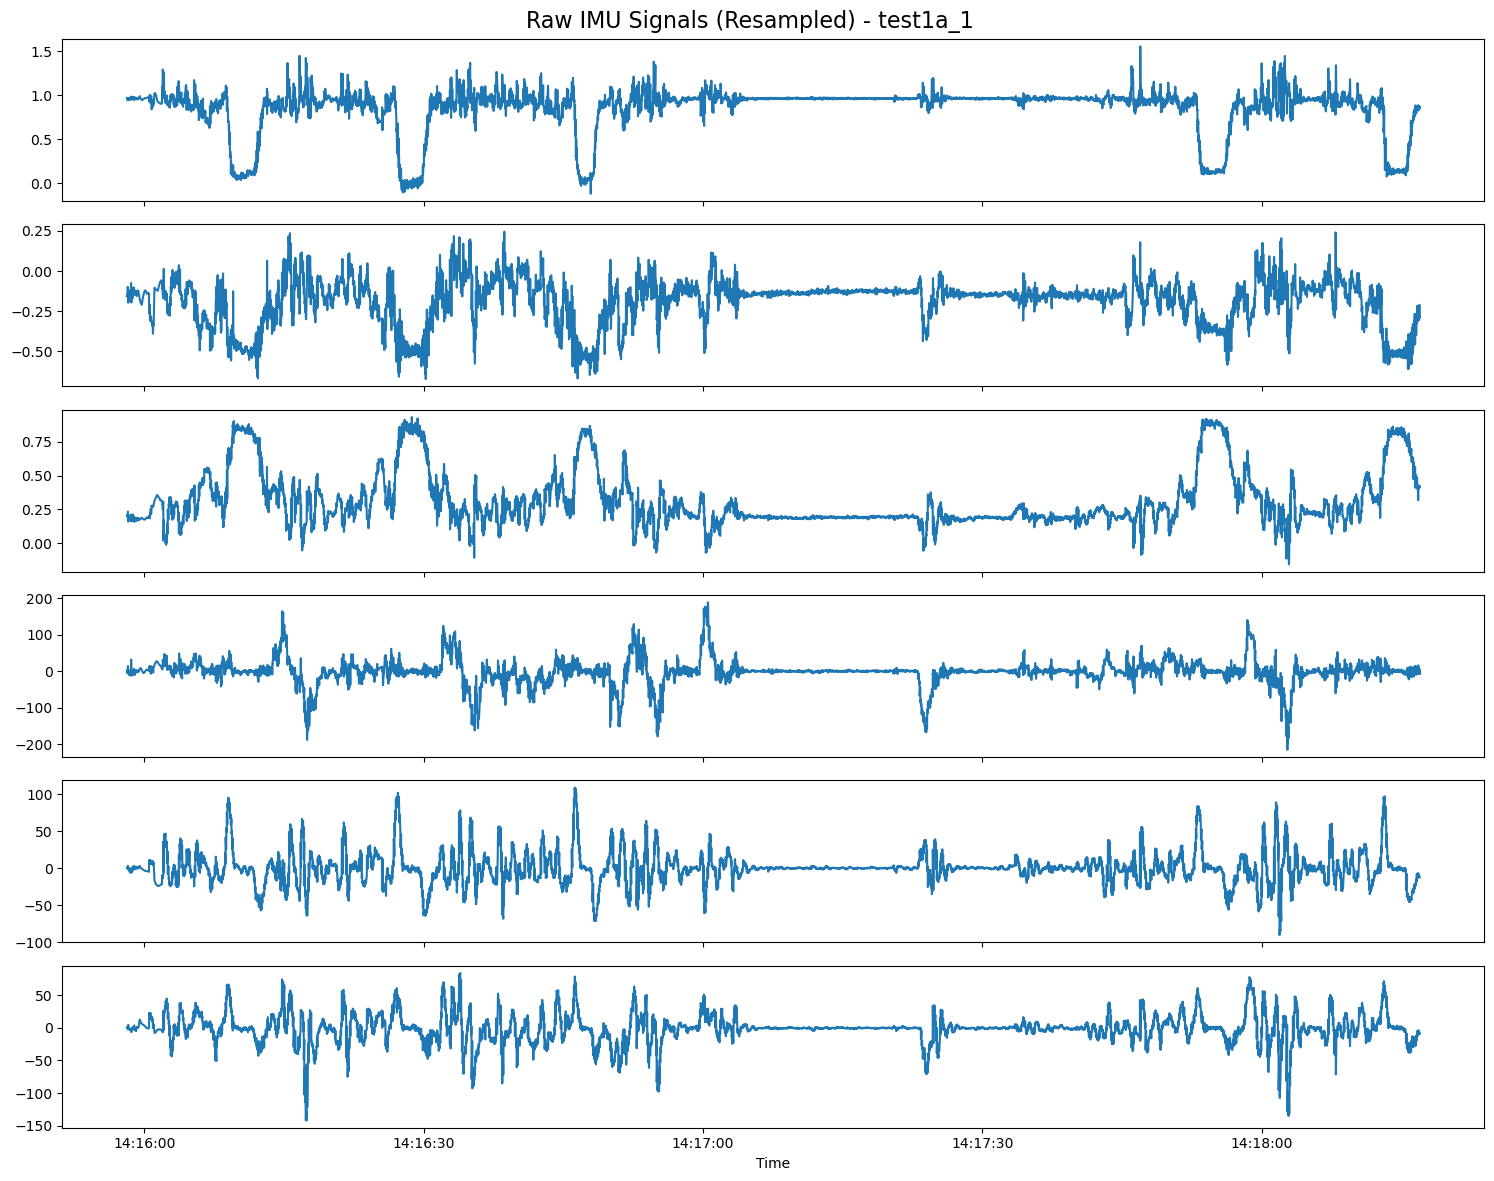

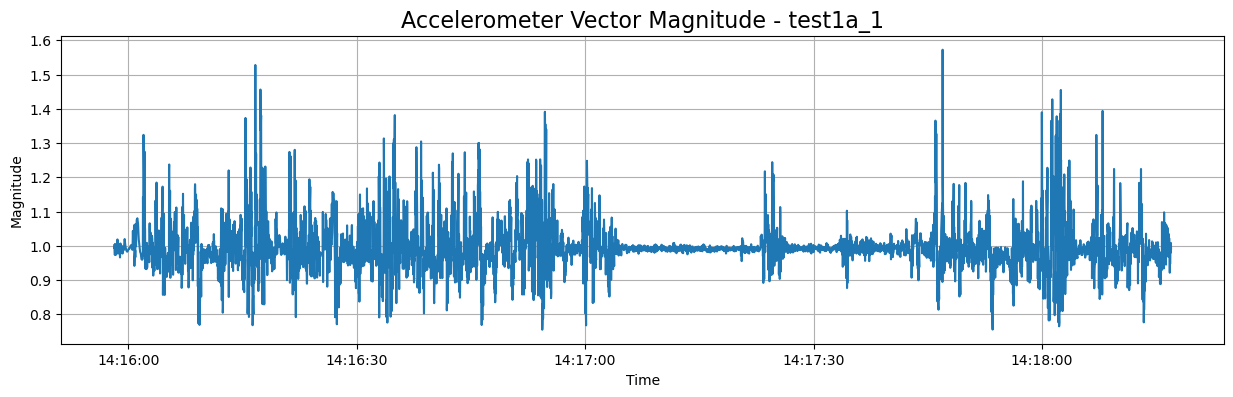

In [123]:
# --- 7. PLOTTING DI ESEMPIO (dopo il loop) ---
# Usiamo il primo DataFrame che abbiamo processato (dal tuo TRIALS_TO_PROCESS)
key_del_primo_file = "test1a_1"

if key_del_primo_file in processed_dataframes:
    print(f"\n--- Genero i grafici di esempio per: {key_del_primo_file} ---")
    
    # Prendiamo il DataFrame corretto dal nostro dizionario
    df_to_plot = processed_dataframes[key_del_primo_file]

    # --- Plot 1: Tutti i 6 Assi (come hai chiesto) ---
    fig, axs = plt.subplots(6, 1, figsize=(15, 12), sharex=True)
    
    # Nota: Usiamo df_to_plot.index (i nostri timestamp corretti) per l'asse X
    axs[0].plot(df_to_plot.index, df_to_plot['ACC_X'], label='ACC_X')
    axs[1].plot(df_to_plot.index, df_to_plot['ACC_Y'], label='ACC_Y')
    axs[2].plot(df_to_plot.index, df_to_plot['ACC_Z'], label='ACC_Z')
    axs[3].plot(df_to_plot.index, df_to_plot['GYR_X'], label='GYR_X')
    axs[4].plot(df_to_plot.index, df_to_plot['GYR_Y'], label='GYR_Y')
    axs[5].plot(df_to_plot.index, df_to_plot['GYR_Z'], label='GYR_Z')

    fig.suptitle(f'Raw IMU Signals (Resampled) - {key_del_primo_file}', fontsize=16)
    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Vector Magnitude (come hai chiesto) ---

    # Calcola il Vector Magnitude
    # (Lo aggiungiamo al DataFrame per poterlo plottare)
    if 'ACC_Mag' not in df_to_plot.columns:
        df_to_plot['ACC_Mag'] = np.sqrt(df_to_plot['ACC_X']**2 + 
                                        df_to_plot['ACC_Y']**2 + 
                                        df_to_plot['ACC_Z']**2)

    # Plotta solo questo
    plt.figure(figsize=(15, 4))
    plt.plot(df_to_plot.index, df_to_plot['ACC_Mag'])
    plt.title(f'Accelerometer Vector Magnitude - {key_del_primo_file}', fontsize=16)
    plt.xlabel('Time')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.show()

else:
    print(f"\nATTENZIONE: Il DataFrame '{key_del_primo_file}' non è stato trovato in 'processed_dataframes'.")
    print("Impossibile generare i grafici di esempio.")


--- Calcolo 'Jerk' per tutti i 6 DataFrame... ---
Jerk calcolato per: test1a_1
Jerk calcolato per: test1a_2
Jerk calcolato per: test1b_1
Jerk calcolato per: test2a_3
Jerk calcolato per: test2a_4
Jerk calcolato per: test2b_5
--- Calcolo Jerk completato. ---

--- Mostro il grafico 'Jerk' di esempio per: test1a_1 ---


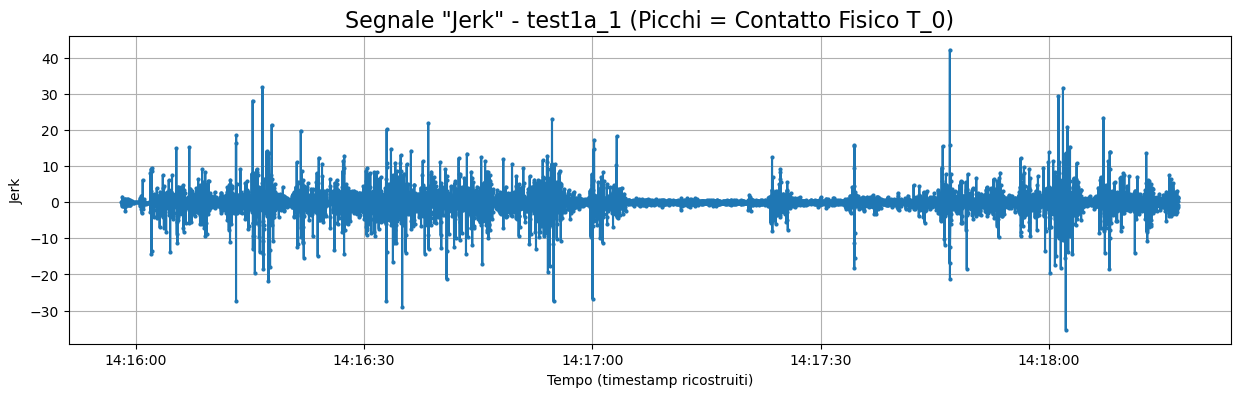

In [124]:
# --- 6. CALCOLO DEL JERK PER TUTTI I DATAFRAME PROCESSATI ---

print(f"\n--- Calcolo 'Jerk' per tutti i {len(processed_dataframes)} DataFrame... ---")

for trial_key, df_corrente in processed_dataframes.items():
    
    # 1. Calcola il Vector Magnitude
    df_corrente['ACC_Mag'] = np.sqrt(df_corrente['ACC_X']**2 + 
                                     df_corrente['ACC_Y']**2 + 
                                     df_corrente['ACC_Z']**2)

    # 2. Calcola il Jerk
    # .diff() calcola la differenza tra una riga e la precedente
    delta_t = df_corrente.index.to_series().diff().dt.total_seconds()
    delta_acc = df_corrente['ACC_Mag'].diff()
    
    # Aggiungi la colonna Jerk. 
    # Usiamo .fillna(0) per riempire il primo valore (che è sempre NaN)
    df_corrente['Jerk'] = (delta_acc / delta_t).fillna(0)
    
    print(f"Jerk calcolato per: {trial_key}")

print("--- Calcolo Jerk completato. ---")


# --- 7. PLOT DI ESEMPIO (SOLO PER IL PRIMO FILE) ---

# Prendiamo la chiave del primo file che abbiamo processato 
# (basandoci sulla tua lista TRIALS_TO_PROCESS)
if TRIALS_TO_PROCESS: # Controlla che la lista non sia vuota
    
    # Ricrea la chiave del primo file, es. "test1a_1"
    key_da_plottare = f"{TRIALS_TO_PROCESS[0][0]}_{TRIALS_TO_PROCESS[0][1]}"
    
    if key_da_plottare in processed_dataframes:
        print(f"\n--- Mostro il grafico 'Jerk' di esempio per: {key_da_plottare} ---")
        
        df_to_plot = processed_dataframes[key_da_plottare]
        
        # Plotta il Jerk (come da tuo codice)
        plt.figure(figsize=(15, 4))
        plt.plot(df_to_plot.index, df_to_plot['Jerk'], marker='.', linestyle='-', markersize=4)
        
        plt.title(f'Segnale "Jerk" - {key_da_plottare} (Picchi = Contatto Fisico T_0)', fontsize=16)
        plt.xlabel('Tempo (timestamp ricostruiti)')
        plt.ylabel('Jerk')
        plt.grid(True)
        plt.show()
    else:
        print(f"ERRORE: Impossibile plottare, '{key_da_plottare}' non trovato nel dizionario.")
else:
    print("ATTENZIONE: 'TRIALS_TO_PROCESS' è vuota, nessun grafico da mostrare.")

In [125]:
from scipy.signal import find_peaks
# --- 4. MAPPA DEI TIMESTAMP MYO (LA TUA PARTE "CASARECCIA") ---
#
# Qui è dove devi associare le tue liste di timestamp
# alle chiavi che abbiamo appena creato (es. 'test1a_1')
#
myo_timestamps_map = {

    'test1a_1': [
'14_16_09_210',
'14_16_27_140',
'14_16_46_575',
'14_17_53_239',
'14_18_13_224',




    ],
    
    'test1a_2': [
'14_18_44_170',
'14_20_01_303',
'14_20_35_785',
'14_20_39_135',




    ],
    
            'test1b_1': [
'14_24_40_767',
'14_25_00_278',
'14_25_10_538',
'14_26_21_836',
'14_26_27_712',
'14_26_47_242',
'14_27_34_627',
'14_27_51_693',
'14_28_05_755',

    ],
    

            'test2a_3': [
'14_30_56_653',
'14_31_06_156',
'14_31_20_961',
'14_31_36_934',

    ],
    
            'test2a_4': [
'14_32_01_370',
'14_32_13_217',
    ],
    
    

        'test2b_5': [
'14_34_24_983',
'14_34_34_892',
'14_34_38_880',
'14_34_53_799',
'14_35_06_836',
'14_35_21_668',


    ],
    


       
}
print(f"Mappa dei timestamp Myo caricata per {len(myo_timestamps_map)} prove.")


# --- 5. LOOP DI RICERCA VINCOLATA (Il tuo codice, ora in un loop) ---
#
# Dizionario dove salveremo i risultati (le latenze)
all_latencies = {} 

# Parametri di ricerca 
WINDOW_START_MS = 1500
WINDOW_END_MS = 0
H_MINIMA = 1
P_MINIMA = 3     
D_MINIMA = 30 # Nota: 100 campioni a 50Hz = 2 secondi. Forse intendevi 10? (200ms)

print("\n--- Avvio Ricerca Vincolata (T_0) per tutte le prove... ---")

# Iteriamo sui DataFrame Jerk che abbiamo creato
for trial_key, df_jerk_data in processed_dataframes.items():
    
    print(f"Processo T_0 per: {trial_key}")
    
    # --- 5a. Associa i dati ---
    if trial_key not in myo_timestamps_map:
        print(f"ATTENZIONE: Timestamp Myo non trovati per {trial_key}. Salto.")
        continue
        
    timestamp_strings = myo_timestamps_map[trial_key]
    
    try:
        timestamps_predizioni_myo = pd.to_datetime(timestamp_strings, format='%H_%M_%S_%f')
    except Exception as e:
        print(f"Errore conversione timestamp per {trial_key}: {e}")
        continue

    # --- 5b. Esegui la ricerca (il tuo codice) ---
    timestamps_contatto_reale = []
    predizioni_myo_corrispondenti = [] # Serve per allineare i dati
    
    for T_myo in timestamps_predizioni_myo:
        T_search_start = T_myo - pd.Timedelta(milliseconds=WINDOW_START_MS)
        T_search_end = T_myo + pd.Timedelta(milliseconds=WINDOW_END_MS)
        
        try:
            jerk_window = df_jerk_data.loc[T_search_start:T_search_end, 'Jerk'].fillna(0)
        except Exception:
            # print(f"Avviso (T_myo fuori range): {T_myo}")
            continue
            
        if jerk_window.empty:
            # print(f"Avviso (finestra vuota): {T_myo}")
            continue

        peak_indices, properties = find_peaks(
            jerk_window.values, height=H_MINIMA, prominence=P_MINIMA, distance=D_MINIMA
        )
        
        if len(peak_indices) == 0:
            # print(f"Avviso (Nessun picco T_0): {T_myo}")
            continue
        
        best_peak_index_in_window = np.argmax(properties['prominences'])
        real_index_in_jerk_window = peak_indices[best_peak_index_in_window]
        T_0_reale = jerk_window.index[real_index_in_jerk_window]
        
        timestamps_contatto_reale.append(T_0_reale)
        predizioni_myo_corrispondenti.append(T_myo) # Salva il T_myo corrispondente

    print(f"Trovati {len(timestamps_contatto_reale)} contatti T_0 su {len(timestamp_strings)} predizioni.")
    
    # --- 5c. Calcola e Salva le Latenze (per questa prova) ---
    if timestamps_contatto_reale:
        t_reali = pd.Series(timestamps_contatto_reale)
        t_myo = pd.Series(predizioni_myo_corrispondenti)
        
        latencies_ms = (t_myo - t_reali).dt.total_seconds() * 1000
        all_latencies[trial_key] = latencies_ms # Salva la Serie di latenze
    else:
        all_latencies[trial_key] = pd.Series(dtype=float) # Salva una serie vuota


# --- 6. RISULTATI FINALI E SALVATAGGIO CSV (come da tua richiesta) ---

print("\n--- Ricerca completata. Aggregazione di tutte le latenze... ---")

# Unisci tutte le serie di latenze da 'all_latencies' in un'unica grande serie
try:
    final_latency_series = pd.concat(all_latencies.values(), ignore_index=True)
except ValueError:
    print("ERRORE: Nessuna latenza trovata in nessuna prova.")
    final_latency_series = pd.Series(dtype=float)


if not final_latency_series.empty:
    print("\n--- STATISTICHE GLOBALI SULLA LATENZA (T_myo - T_reale) ---")
    print(f"Latenza Media: {final_latency_series.mean():.2f} ms")
    print(f"Deviazione Std: {final_latency_series.std():.2f} ms")
    print(f"Mediana: {final_latency_series.median():.2f} ms")
    print(f"Min: {final_latency_series.min():.2f} ms | Max: {final_latency_series.max():.2f} ms")
    print(f"Numero totale di latenze calcolate: {len(final_latency_series)}")
    
    # Creazione del percorso di salvataggio CSV (come da tua richiesta)
    save_dir = os.path.join(r'../data', f'S{SUBJECT_ID}', 'delay')
    os.makedirs(save_dir, exist_ok=True) # Crea le cartelle se non esistono
    
    # Salviamo TUTTE le latenze in un unico file CSV per questo soggetto
    csv_filename = os.path.join(save_dir, f'S{SUBJECT_ID}_all_latencies.csv')
    
    # Creiamo un bel DataFrame
    final_df_to_save = pd.DataFrame({'Latency_ms': final_latency_series})
    final_df_to_save.to_csv(csv_filename, sep=';', index=False, decimal='.')
    
    print(f"\nTutte le {len(final_latency_series)} latenze salvate in: {csv_filename}")
else:
    print("Elaborazione terminata. Nessuna latenza è stata calcolata.")

Mappa dei timestamp Myo caricata per 6 prove.

--- Avvio Ricerca Vincolata (T_0) per tutte le prove... ---
Processo T_0 per: test1a_1
Trovati 5 contatti T_0 su 5 predizioni.
Processo T_0 per: test1a_2
Trovati 4 contatti T_0 su 4 predizioni.
Processo T_0 per: test1b_1
Trovati 9 contatti T_0 su 9 predizioni.
Processo T_0 per: test2a_3
Trovati 4 contatti T_0 su 4 predizioni.
Processo T_0 per: test2a_4
Trovati 2 contatti T_0 su 2 predizioni.
Processo T_0 per: test2b_5
Trovati 6 contatti T_0 su 6 predizioni.

--- Ricerca completata. Aggregazione di tutte le latenze... ---

--- STATISTICHE GLOBALI SULLA LATENZA (T_myo - T_reale) ---
Latenza Media: 650.06 ms
Deviazione Std: 313.43 ms
Mediana: 600.65 ms
Min: 203.00 ms | Max: 1410.75 ms
Numero totale di latenze calcolate: 30

Tutte le 30 latenze salvate in: ../data\S17\delay\S17_all_latencies.csv
